# NMR Hybrid Physics-Aware AI Pipeline — Flow Validation Test

This notebook demonstrates the end-to-end pipeline described in `NMR_DEEP_HANDBOOK.md`, including:
1. Loading and preprocessing simulated NMR mixture data
2. Injecting noise, drift, and ghost peaks
3. Loading a pre-trained 1D-ResNet model, freezing backbone layers, and projecting to 512 dimensions
4. Sim2Real pretraining on 1,000 synthetic samples
5. Fine-tuning on real NMRQNet data with a Neural ODE solver, Decoder, and Localized Patch EBM
6. Compound matching using Constrained DTW and Hybrid Matching Score

In [2]:
import sys
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.signal import decimate

# Add resnet1d path for importing the Net1D module
sys.path.append(os.path.abspath("../resnet1d"))
from net1d import Net1D, MyConv1dPadSame, Swish, BasicStage, BasicBlock, MyMaxPool1dPadSame

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
# Load simulated mixtures and concentrations
mixtures_path = "../NMRQNet/simulated_mixtures_highres.csv"
concentrations_path = "../NMRQNet/ground_truth_concentrations.csv"

print("Loading datasets...")
df_mixtures = pd.read_csv(mixtures_path)
df_concentrations = pd.read_csv(concentrations_path)

# Extract SampleID and ppm axes
sample_ids = df_mixtures["SampleID"].values
ppm_cols = [float(col) for col in df_mixtures.columns if col != "SampleID"]
ppm_axis = np.array(ppm_cols)

# Features: shape (n_samples, 40000)
X = df_mixtures.drop(columns=["SampleID"]).values
# Targets: shape (n_samples, 9)
Y = df_concentrations.drop(columns=["SampleID"]).values
metabolites = [col for col in df_concentrations.columns if col != "SampleID"]

print(f"Original mixtures shape: {X.shape}")
print(f"Concentrations shape: {Y.shape}")
print(f"Metabolites: {metabolites}")

# Take only 15 samples for POC testing
n_poc_samples = 15
X_poc = X[:n_poc_samples]
Y_poc = Y[:n_poc_samples]

# Downsample by 40x using step slicing to get ~1000 points
downsample_factor = 40
X_downsampled = X_poc[:, ::downsample_factor]
ppm_axis_downsampled = ppm_axis[::downsample_factor]

print(f"Downsampled mixtures shape: {X_downsampled.shape}")
print(f"Downsampled ppm axis length: {len(ppm_axis_downsampled)}")

Loading datasets...
Original mixtures shape: (100, 40000)
Concentrations shape: (100, 9)
Metabolites: ['Choline', 'Cysteine', 'Glucose', 'Glutamate', 'Glycine', 'Leucine', 'Lysine', 'Myo_inositol', 'Tryptophan']
Downsampled mixtures shape: (15, 1000)
Downsampled ppm axis length: 1000


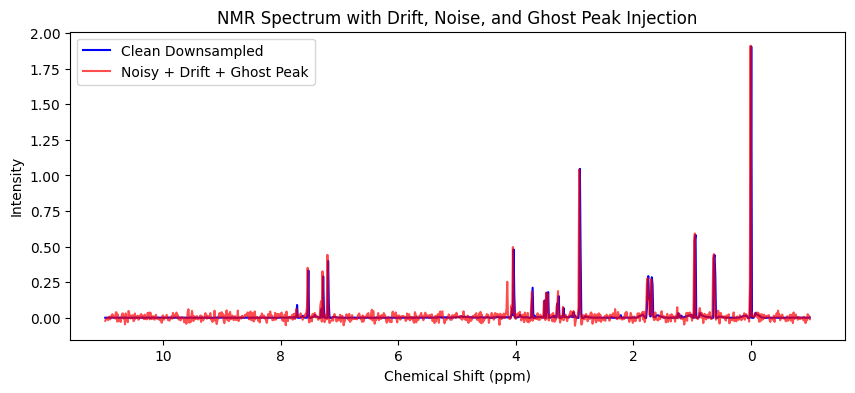

In [4]:
class NMRNoiseInjector:
    def __init__(self, ppm_axis):
        self.ppm_axis = ppm_axis
        
    def add_drift(self, spectrum, shift_points):
        # Shift spectrum by shift_points (stochastic shift drift)
        return np.roll(spectrum, shift_points)
        
    def add_ghost_peak(self, spectrum, peak_ppm=4.15, amplitude=0.5, lw=0.005):
        # Add narrow Lorentzian ghost peak
        # Lorentzian formula: A * lw^2 / ((ppm - peak_ppm)^2 + lw^2)
        ghost = amplitude * (lw**2) / ((self.ppm_axis - peak_ppm)**2 + lw**2)
        return spectrum + ghost
        
    def add_gaussian_noise(self, spectrum, sigma_ratio=0.01):
        # Add additive white Gaussian noise
        max_val = np.max(spectrum)
        noise = np.random.normal(0, sigma_ratio * max_val, len(spectrum))
        return spectrum + noise
        
    def inject(self, spectrum, shift_points=5, ghost_amp=0.5, noise_sigma=0.01):
        spec = self.add_drift(spectrum, shift_points)
        spec = self.add_ghost_peak(spec, amplitude=ghost_amp)
        spec = self.add_gaussian_noise(spec, sigma_ratio=noise_sigma)
        return spec

injector = NMRNoiseInjector(ppm_axis_downsampled)

# Generate a noisy version of the downsampled mixtures
X_noisy = np.zeros_like(X_downsampled)
for i in range(len(X_downsampled)):
    # Inject randomly: shift by -5 to +5, ghost amplitude 0.2 to 0.5, noise 0.01
    shift = np.random.randint(-5, 6)
    X_noisy[i] = injector.inject(X_downsampled[i], shift_points=shift, ghost_amp=0.3)

# Plot an example
plt.figure(figsize=(10, 4))
plt.plot(ppm_axis_downsampled, X_downsampled[0], label="Clean Downsampled", color="blue")
plt.plot(ppm_axis_downsampled, X_noisy[0], label="Noisy + Drift + Ghost Peak", color="red", alpha=0.7)
plt.title("NMR Spectrum with Drift, Noise, and Ghost Peak Injection")
plt.xlabel("Chemical Shift (ppm)")
plt.ylabel("Intensity")
plt.legend()
plt.gca().invert_xaxis() # NMR spectra traditionally read right-to-left
plt.show()

In [5]:
# We need to simulate 1,000 synthetic samples for Sim2Real Pretraining
class NMRDataSimulator:
    def __init__(self, ppm_axis, num_metabolites=9):
        self.ppm_axis = ppm_axis
        self.num_metabolites = num_metabolites
        
    def generate_lorentzian_peak(self, x0, intensity, lw):
        return intensity * (lw**2) / ((self.ppm_axis - x0)**2 + lw**2)
        
    def simulate_sample(self):
        # Generate a clean spectrum with random Lorentzian peaks
        # Randomly select between 2 and 5 active metabolites/peaks
        num_peaks = np.random.randint(3, 8)
        clean = np.zeros_like(self.ppm_axis)
        
        # Add random peaks (representing metabolites)
        for _ in range(num_peaks):
            x0 = np.random.uniform(0.5, 9.0) # ppm range
            intensity = np.random.uniform(0.1, 1.0)
            lw = np.random.uniform(0.003, 0.01)
            clean += self.generate_lorentzian_peak(x0, intensity, lw)
            
        return clean

# Generate 1,000 synthetic samples
simulator = NMRDataSimulator(ppm_axis_downsampled)
print("Generating 1,000 synthetic samples for pretraining...")
X_synth_clean = np.zeros((1000, len(ppm_axis_downsampled)))
X_synth_noisy = np.zeros((1000, len(ppm_axis_downsampled)))

for i in range(1000):
    clean = simulator.simulate_sample()
    X_synth_clean[i] = clean
    
    # Inject noise/drift/ghosts into synthetic data
    shift = np.random.randint(-5, 6)
    # 50% chance of ghost peak
    ghost_amp = np.random.uniform(0.2, 0.5) if np.random.rand() > 0.5 else 0.0
    X_synth_noisy[i] = injector.inject(clean, shift_points=shift, ghost_amp=ghost_amp)

print("Synthetic data generated successfully.")

Generating 1,000 synthetic samples for pretraining...
Synthetic data generated successfully.


In [6]:
# Define the wrapper class for loading model.pth and adding projection head
class PretrainedResNetEncoder(nn.Module):
    def __init__(self, pretrained_model_path, output_dim=512, freeze_backbone=True):
        super().__init__()
        # Load the pre-trained Net1D model
        print(f"Loading pretrained weights from {pretrained_model_path}...")
        self.backbone = torch.load(pretrained_model_path, map_location="cpu", weights_only=False)
        
        # Freeze backbone parameters
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            print("Backbone layers frozen.")
        else:
            print("Backbone layers trainable.")
            
        # The output dimension of backbone's last stage (before dense layer) is 1024
        # We project it to 512 dimensions
        self.projection_head = nn.Linear(1024, output_dim)
        
    def forward(self, x):
        # x shape: (batch, 1, seq_len)
        # We need to forward through the backbone (excluding its final dense layer)
        out = x
        
        # first conv
        out = self.backbone.first_conv(out)
        if self.backbone.use_bn:
            out = self.backbone.first_bn(out)
        out = self.backbone.first_activation(out)
        
        # stages
        for i_stage in range(self.backbone.n_stages):
            net = self.backbone.stage_list[i_stage]
            out = net(out)
            
        # Global average pooling
        out = out.mean(-1) # shape: (batch, 1024)
        
        # Projection to 512 dims
        out = self.projection_head(out) # shape: (batch, 512)
        return out

pretrained_path = "../resnet1d/trained_model/model.pth"
encoder = PretrainedResNetEncoder(pretrained_path, output_dim=512, freeze_backbone=True).to(device)

# Test shape
test_x = torch.randn(2, 1, len(ppm_axis_downsampled)).to(device)
with torch.no_grad():
    test_out = encoder(test_x)
print(f"Encoder test input: {test_x.shape} -> output: {test_out.shape}")

Loading pretrained weights from ../resnet1d/trained_model/model.pth...
Backbone layers frozen.
Encoder test input: torch.Size([2, 1, 1000]) -> output: torch.Size([2, 512])


In [7]:
# Stage 2: LatentSpaceODESolver
# Learn a continuous vector field to align drifted latent space representations
from torchdiffeq import odeint

class ODEFunc(nn.Module):
    def __init__(self, dim=512):
        super().__init__()
        # Simple MLP: 512 -> 1024 -> 512 to learn vector field
        self.net = nn.Sequential( 
            nn.Linear(dim, 1024),
            nn.GELU(),
            nn.Linear(1024, dim)
        )
        
    def forward(self, t, h):
        # dh/dt = f(h, t)
        return self.net(h)

class LatentSpaceODESolver(nn.Module):
    def __init__(self, ode_func, t_end=1.0, steps=4):
        super().__init__()
        self.ode_func = ode_func
        self.t = torch.linspace(0.0, t_end, steps)
        
    def forward(self, h0):
        # Integrate from t=0 to t_end
        # odeint returns shape (steps, batch, dim)
        # We take the final step output h(T)
        solutions = odeint(self.ode_func, h0, self.t.to(h0.device), method="euler")
        return solutions[-1]

ode_func = ODEFunc(dim=512).to(device)
ode_solver = LatentSpaceODESolver(ode_func).to(device)

with torch.no_grad():
    ode_out = ode_solver(test_out)
print(f"ODE output shape: {ode_out.shape}")

ODE output shape: torch.Size([2, 512])


In [8]:
# Stage 3: SpectrumDecoder + LocalizedPatchEBM
class SpectrumDecoder(nn.Module):
    def __init__(self, latent_dim=512, output_len=1000):
        super().__init__()
        self.output_len = output_len
        
        # Project latent to feature map
        self.fc = nn.Linear(latent_dim, 64 * 128)
        
        # Transposed 1D convolutions to reconstruct spectrum
        self.deconv1 = nn.ConvTranspose1d(64, 16, kernel_size=7, stride=2, padding=1)
        self.deconv2 = nn.ConvTranspose1d(16, 1, kernel_size=15, stride=2, padding=2)
        
        # Final adjustment layer to get exact output length
        self.fc_out = nn.Linear(527, output_len) # 527 is the output len of deconvs, we map to output_len
        
    def forward(self, h):
        # h shape: (batch, 512)
        out = self.fc(h)
        out = out.view(-1, 64, 128)
        
        out = F.gelu(self.deconv1(out))
        out = F.gelu(self.deconv2(out)) # shape: (batch, 1, 527)
        
        # Map to output length
        out = self.fc_out(out) # shape: (batch, 1, output_len)
        return out

decoder = SpectrumDecoder(latent_dim=512, output_len=len(ppm_axis_downsampled)).to(device)
with torch.no_grad():
    decoder_out = decoder(ode_out)
print(f"Decoder output shape: {decoder_out.shape}")

class LocalizedPatchEBM(nn.Module):
    def __init__(self, ppm_axis):
        super().__init__()
        self.ppm_axis = ppm_axis
        self.num_points = len(ppm_axis)
        
        # Identify indices for 3 zones
        # 1. Aliphatic (0.5 - 3.0 ppm)
        # 2. Carbohydrate (3.0 - 5.5 ppm)
        # 3. Aromatic (5.5 - 9.0 ppm)
        self.aliphatic_idx = np.where((ppm_axis >= 0.5) & (ppm_axis < 3.0))[0]
        self.carbo_idx = np.where((ppm_axis >= 3.0) & (ppm_axis < 5.5))[0]
        self.aromatic_idx = np.where((ppm_axis >= 5.5) & (ppm_axis <= 9.0))[0]
        
        # Small MLPs for energy per patch
        self.mlp_aliphatic = self._make_mlp(len(self.aliphatic_idx))
        self.mlp_carbo = self._make_mlp(len(self.carbo_idx))
        self.mlp_aromatic = self._make_mlp(len(self.aromatic_idx))
        
        # Zone weights
        self.w1 = 0.4
        self.w2 = 0.4
        self.w3 = 0.2
        
    def _make_mlp(self, input_dim):
        dim = input_dim if input_dim > 0 else 1
        return nn.Sequential(
            nn.Linear(dim, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        # x shape: (batch, 1, seq_len)
        batch_size = x.shape[0]
        x_flat = x.squeeze(1) # (batch, seq_len)
        
        # Extract patches
        p1 = x_flat[:, self.aliphatic_idx] if len(self.aliphatic_idx) > 0 else torch.zeros(batch_size, 1).to(x.device)
        p2 = x_flat[:, self.carbo_idx] if len(self.carbo_idx) > 0 else torch.zeros(batch_size, 1).to(x.device)
        p3 = x_flat[:, self.aromatic_idx] if len(self.aromatic_idx) > 0 else torch.zeros(batch_size, 1).to(x.device)
        
        # Compute patch energies
        e1 = self.mlp_aliphatic(p1).squeeze(-1)
        e2 = self.mlp_carbo(p2).squeeze(-1)
        e3 = self.mlp_aromatic(p3).squeeze(-1)
        
        # Global Energy
        e_global = self.w1 * e1 + self.w2 * e2 + self.w3 * e3
        return e_global, (e1, e2, e3)

ebm = LocalizedPatchEBM(ppm_axis_downsampled).to(device)
with torch.no_grad():
    ebm_out, energies = ebm(decoder_out)
print(f"EBM global energy shape: {ebm_out.shape}")

Decoder output shape: torch.Size([2, 1, 1000])
EBM global energy shape: torch.Size([2])


Starting Sim2Real Pretraining (Phase 1)...
Epoch 01/20 | Train Loss: 0.002261 | Val Loss: 0.001700
Epoch 05/20 | Train Loss: 0.001600 | Val Loss: 0.001600
Epoch 10/20 | Train Loss: 0.001588 | Val Loss: 0.001600
Epoch 15/20 | Train Loss: 0.001579 | Val Loss: 0.001599
Epoch 20/20 | Train Loss: 0.001568 | Val Loss: 0.001598
Phase 1 Pretraining Completed.


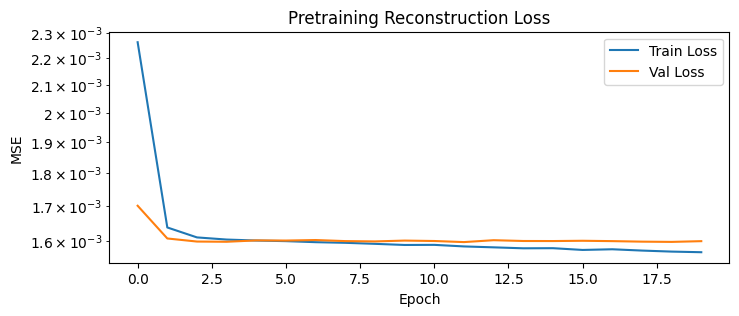

In [9]:
class NMRDataset(Dataset):
    def __init__(self, noisy_data, clean_data):
        self.noisy = torch.tensor(noisy_data, dtype=torch.float32).unsqueeze(1)
        self.clean = torch.tensor(clean_data, dtype=torch.float32).unsqueeze(1)
        
    def __len__(self):
        return len(self.noisy)
        
    def __getitem__(self, idx):
        return self.noisy[idx], self.clean[idx]

# Pretraining datasets & loader
train_synth_dataset = NMRDataset(X_synth_noisy[:800], X_synth_clean[:800])
val_synth_dataset = NMRDataset(X_synth_noisy[800:], X_synth_clean[800:])

train_synth_loader = DataLoader(train_synth_dataset, batch_size=32, shuffle=True)
val_synth_loader = DataLoader(val_synth_dataset, batch_size=32, shuffle=False)

# Phase 1 Optimization (Pretraining Encoder projection head & Decoder)
optimizer_pretrain = optim.Adam(
    list(encoder.projection_head.parameters()) + list(decoder.parameters()), 
    lr=1e-3
)
criterion_mse = nn.MSELoss()

print("Starting Sim2Real Pretraining (Phase 1)...")
epochs_pretrain = 20
train_losses = []
val_losses = []

for epoch in range(epochs_pretrain):
    encoder.train()
    decoder.train()
    epoch_loss = 0
    for noisy, clean in train_synth_loader:
        noisy, clean = noisy.to(device), clean.to(device)
        
        latent = encoder(noisy)
        reconstructed = decoder(latent)
        
        loss = criterion_mse(reconstructed, clean)
        
        optimizer_pretrain.zero_grad()
        loss.backward()
        optimizer_pretrain.step()
        
        epoch_loss += loss.item() * noisy.size(0)
        
    epoch_loss /= len(train_synth_loader.dataset)
    train_losses.append(epoch_loss)
    
    # Validation
    encoder.eval()
    decoder.eval()
    val_loss = 0
    with torch.no_grad():
        for noisy, clean in val_synth_loader:
            noisy, clean = noisy.to(device), clean.to(device)
            latent = encoder(noisy)
            reconstructed = decoder(latent)
            loss = criterion_mse(reconstructed, clean)
            val_loss += loss.item() * noisy.size(0)
    val_loss /= len(val_synth_loader.dataset)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{epochs_pretrain:02d} | Train Loss: {epoch_loss:.6f} | Val Loss: {val_loss:.6f}")

print("Phase 1 Pretraining Completed.")

plt.figure(figsize=(8, 3))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Pretraining Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.yscale('log')
plt.legend()
plt.show()

In [10]:
# Real Data: 12 train / 3 val split
X_train_real, X_val_real = X_noisy[:12], X_noisy[12:15]
X_train_clean, X_val_clean = X_downsampled[:12], X_downsampled[12:15]

train_real_dataset = NMRDataset(X_train_real, X_train_clean)
val_real_dataset = NMRDataset(X_val_real, X_val_clean)

train_real_loader = DataLoader(train_real_dataset, batch_size=4, shuffle=True)
val_real_loader = DataLoader(val_real_dataset, batch_size=4, shuffle=False)

# Fine-tune Optimizer: include ODE, Decoder, and Projection Head
optimizer_finetune = optim.Adam(
    list(encoder.projection_head.parameters()) + 
    list(ode_func.parameters()) + 
    list(decoder.parameters()) +
    list(ebm.parameters()), 
    lr=5e-4
)

# Contrastive Margin Loss for EBM
def contrastive_ebm_loss(pos_energy, neg_energy, margin=1.0):
    loss = pos_energy.mean() + torch.clamp(margin - neg_energy + pos_energy, min=0.0).mean()
    return loss

print("Starting Fine-tuning (Phase 2)...")
epochs_finetune = 30
lambda_ebm = 0.1

for epoch in range(epochs_finetune):
    encoder.train()
    ode_func.train()
    decoder.train()
    ebm.train()
    
    epoch_mse = 0
    epoch_ebm = 0
    
    for noisy, clean in train_real_loader:
        noisy, clean = noisy.to(device), clean.to(device)
        
        latent_noisy = encoder(noisy)
        aligned_latent = ode_solver(latent_noisy)
        reconstructed = decoder(aligned_latent)
        
        loss_mse = criterion_mse(reconstructed, clean)
        
        pos_energy, _ = ebm(clean)
        neg_energy, _ = ebm(noisy)
        loss_ebm = contrastive_ebm_loss(pos_energy, neg_energy, margin=1.0)
        
        loss = loss_mse + lambda_ebm * loss_ebm
        
        optimizer_finetune.zero_grad()
        loss.backward()
        optimizer_finetune.step()
        
        epoch_mse += loss_mse.item() * noisy.size(0)
        epoch_ebm += loss_ebm.item() * noisy.size(0)
        
    epoch_mse /= len(train_real_loader.dataset)
    epoch_ebm /= len(train_real_loader.dataset)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{epochs_finetune:02d} | MSE Loss: {epoch_mse:.6f} | EBM Loss: {epoch_ebm:.6f}")

print("Phase 2 Fine-tuning Completed.")

Starting Fine-tuning (Phase 2)...
Epoch 01/30 | MSE Loss: 0.004393 | EBM Loss: 1.025120
Epoch 10/30 | MSE Loss: 0.001163 | EBM Loss: 0.810178
Epoch 20/30 | MSE Loss: 0.000864 | EBM Loss: 0.474724
Epoch 30/30 | MSE Loss: 0.000738 | EBM Loss: -0.022934
Phase 2 Fine-tuning Completed.


In [11]:
from scipy.optimize import linear_sum_assignment
from dtw import dtw

# Load reference library
with open("reference_peaks.json", "r") as f:
    ref_lib = json.load(f)["metabolites"]

# Convert pure peaks to spectrum profile for DTW and Bipartite Matching
def generate_reference_profiles(ppm_axis, ref_lib):
    profiles = {}
    for name, data in ref_lib.items():
        spec = np.zeros_like(ppm_axis)
        for peak in data["peaks"]:
            spec += peak["intensity"] * (peak["linewidth"]**2) / ((ppm_axis - peak["ppm"])**2 + peak["linewidth"]**2)
        profiles[name] = spec
    return profiles

ref_profiles = generate_reference_profiles(ppm_axis_downsampled, ref_lib)

def detect_peaks(spectrum, ppm_axis, threshold=0.05):
    peaks = []
    for i in range(1, len(spectrum) - 1):
        if spectrum[i] > spectrum[i-1] and spectrum[i] > spectrum[i+1] and spectrum[i] > threshold:
            peaks.append((ppm_axis[i], spectrum[i]))
    return peaks

def peak_bipartite_assignment(sample_peaks, ref_peaks, tolerance=0.03):
    if not sample_peaks or not ref_peaks:
        return 0.0
        
    cost_matrix = np.zeros((len(sample_peaks), len(ref_peaks)))
    for i, (sp_ppm, sp_int) in enumerate(sample_peaks):
        for j, (rp_ppm, rp_int) in enumerate(ref_peaks):
            dist = abs(sp_ppm - rp_ppm)
            if dist <= tolerance:
                cost_matrix[i, j] = dist + abs(sp_int - rp_int)
            else:
                cost_matrix[i, j] = 999.0
                
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    matched = 0
    for r, c in zip(row_ind, col_ind):
        if cost_matrix[r, c] < 10.0:
            matched += 1
            
    return matched / max(len(sample_peaks), len(ref_peaks))

def compute_hybrid_scores(query_spec, ebm_model, device):
    query_tensor = torch.tensor(query_spec, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    
    with torch.no_grad():
        ebm_energy, _ = ebm_model(query_tensor)
        ebm_energy = ebm_energy.item()
    ebm_confidence = 1.0 / (1.0 + np.exp(ebm_energy - 1.0))
    
    sample_peaks = detect_peaks(query_spec, ppm_axis_downsampled)
    
    scores = {}
    for name, ref_spec in ref_profiles.items():
        alignment = dtw(query_spec, ref_spec, keep_internals=True, window_type="sakoechiba", window_args={"window_size": 15})
        dtw_dist = alignment.normalizedDistance
        dtw_similarity = 1.0 / (1.0 + dtw_dist)
        
        ref_peaks = [(p["ppm"], p["intensity"]) for p in ref_lib[name]["peaks"]]
        bipartite_score = peak_bipartite_assignment(sample_peaks, ref_peaks)
        
        hybrid_score = 0.45 * bipartite_score + 0.35 * dtw_similarity + 0.20 * ebm_confidence
        scores[name] = {
            "HybridScore": float(hybrid_score),
            "PeakAssignment": float(bipartite_score),
            "DTWSimilarity": float(dtw_similarity),
            "EBMConfidence": float(ebm_confidence)
        }
    return scores

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



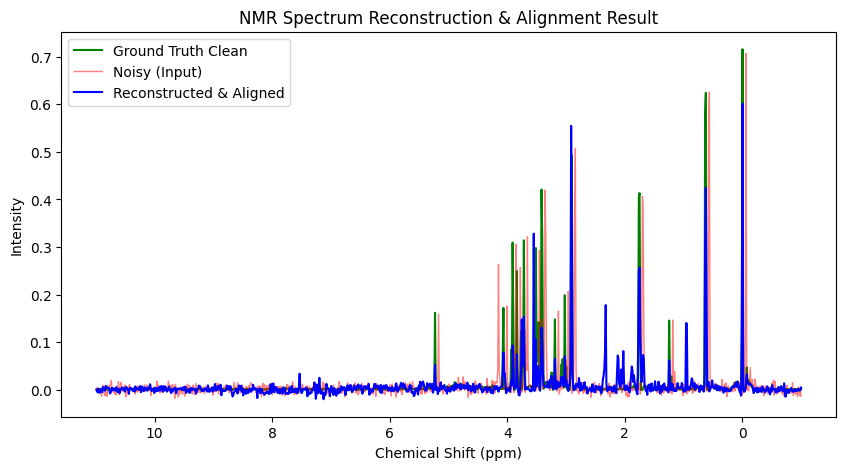

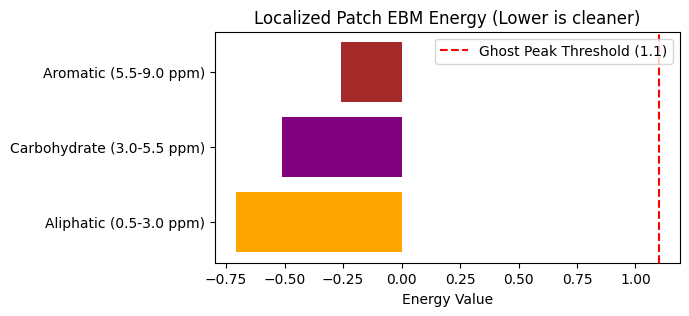

--- Ranked Metabolites Matching Table ---
              HybridScore  PeakAssignment  DTWSimilarity  EBMConfidence
Glucose          0.619170        0.238095       0.992511       0.823243
Glutamate        0.598128        0.190476       0.993616       0.823243
Lysine           0.576828        0.142857       0.993980       0.823243
Choline          0.576730        0.142857       0.993701       0.823243
Leucine          0.576722        0.142857       0.993678       0.823243
Myo_inositol     0.555327        0.095238       0.993774       0.823243
Glycine          0.533907        0.047619       0.993801       0.823243
Cysteine         0.533894        0.047619       0.993762       0.823243
Tryptophan       0.533512        0.047619       0.992670       0.823243

clinical_report.json exported successfully.


In [12]:
# Select a validation sample to visualize
val_idx = 0
noisy_sample = X_val_real[val_idx]
clean_sample = X_val_clean[val_idx]

# Model Inference
encoder.eval()
ode_func.eval()
decoder.eval()
ebm.eval()

with torch.no_grad():
    x_in = torch.tensor(noisy_sample, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    latent = encoder(x_in)
    aligned_latent = ode_solver(latent)
    reconstructed_spec = decoder(aligned_latent).squeeze().cpu().numpy()
    
    _, (e1, e2, e3) = ebm(decoder(aligned_latent))
    ebm_energies = [e1.item(), e2.item(), e3.item()]

# 1. Raw vs Noisy vs Reconstructed Plot
plt.figure(figsize=(10, 5))
plt.plot(ppm_axis_downsampled, clean_sample, label="Ground Truth Clean", color="green", lw=1.5)
plt.plot(ppm_axis_downsampled, noisy_sample, label="Noisy (Input)", color="red", alpha=0.5, lw=1)
plt.plot(ppm_axis_downsampled, reconstructed_spec, label="Reconstructed & Aligned", color="blue", lw=1.5)
plt.title("NMR Spectrum Reconstruction & Alignment Result")
plt.xlabel("Chemical Shift (ppm)")
plt.ylabel("Intensity")
plt.legend()
plt.gca().invert_xaxis()
plt.show()

# 2. EBM Energy per Zone Heatmap
zones = ["Aliphatic (0.5-3.0 ppm)", "Carbohydrate (3.0-5.5 ppm)", "Aromatic (5.5-9.0 ppm)"]
plt.figure(figsize=(6, 3))
plt.barh(zones, ebm_energies, color=["orange", "purple", "brown"])
plt.title("Localized Patch EBM Energy (Lower is cleaner)")
plt.xlabel("Energy Value")
plt.axvline(x=1.1, color="red", linestyle="--", label="Ghost Peak Threshold (1.1)")
plt.legend()
plt.show()

# 3. Run Hybrid Matching
matching_scores = compute_hybrid_scores(reconstructed_spec, ebm, device)
df_scores = pd.DataFrame(matching_scores).T.sort_values(by="HybridScore", ascending=False)
print("--- Ranked Metabolites Matching Table ---")
print(df_scores)

# Write output report clinical_report.json
report = {
    "SampleID": f"Sample_POC_Val_{val_idx}",
    "EBM_Ghost_Peak_Detection": {
        "Global_Energy": float(sum(ebm_energies)),
        "Ghost_Peak_Detected": bool(sum(ebm_energies) > 1.1),
        "Patch_Energies": {
            "Aliphatic": ebm_energies[0],
            "Carbohydrate": ebm_energies[1],
            "Aromatic": ebm_energies[2]
        }
    },
    "Matching_Results": df_scores.to_dict(orient="index")
}

with open("clinical_report.json", "w") as f:
    json.dump(report, f, indent=2)
print("\nclinical_report.json exported successfully.")